# Project Overview: Predicting Formula 1 Pit Stops

**Objective:** To develop a high-performance machine learning model capable of predicting the PitNextLap target variable, leveraging complex telemetry and strategy datasets. 

## 1. Libraries & Workspace Setup

In [73]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s6e5


In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import math
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder
import joblib
import pickle
from IPython.display import FileLink

## 2. Data Acquisition & Initial Inspection

In [75]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

In [76]:
train_df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [77]:
test_df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


### 2.2. Checking Structural Metadata

In [78]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [79]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188165 entries, 0 to 188164
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      188165 non-null  int64  
 1   Driver                  188165 non-null  object 
 2   Compound                188165 non-null  object 
 3   Race                    188165 non-null  object 
 4   Year                    188165 non-null  int64  
 5   PitStop                 188165 non-null  int64  
 6   LapNumber               188165 non-null  int64  
 7   Stint                   188165 non-null  int64  
 8   TyreLife                188165 non-null  float64
 9   Position                188165 non-null  int64  
 10  LapTime (s)             188165 non-null  float64
 11  LapTime_Delta           188165 non-null  float64
 12  Cumulative_Degradation  188165 non-null  float64
 13  RaceProgress            188165 non-null  float64
 14  Position_Change     

In [80]:
train_df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [81]:
test_df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64

## 3. Exploratory Data Analysis

In [82]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,439140.0,219569.500000,126768.942943,0.000000,109784.75000,219569.500000,329354.250000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026


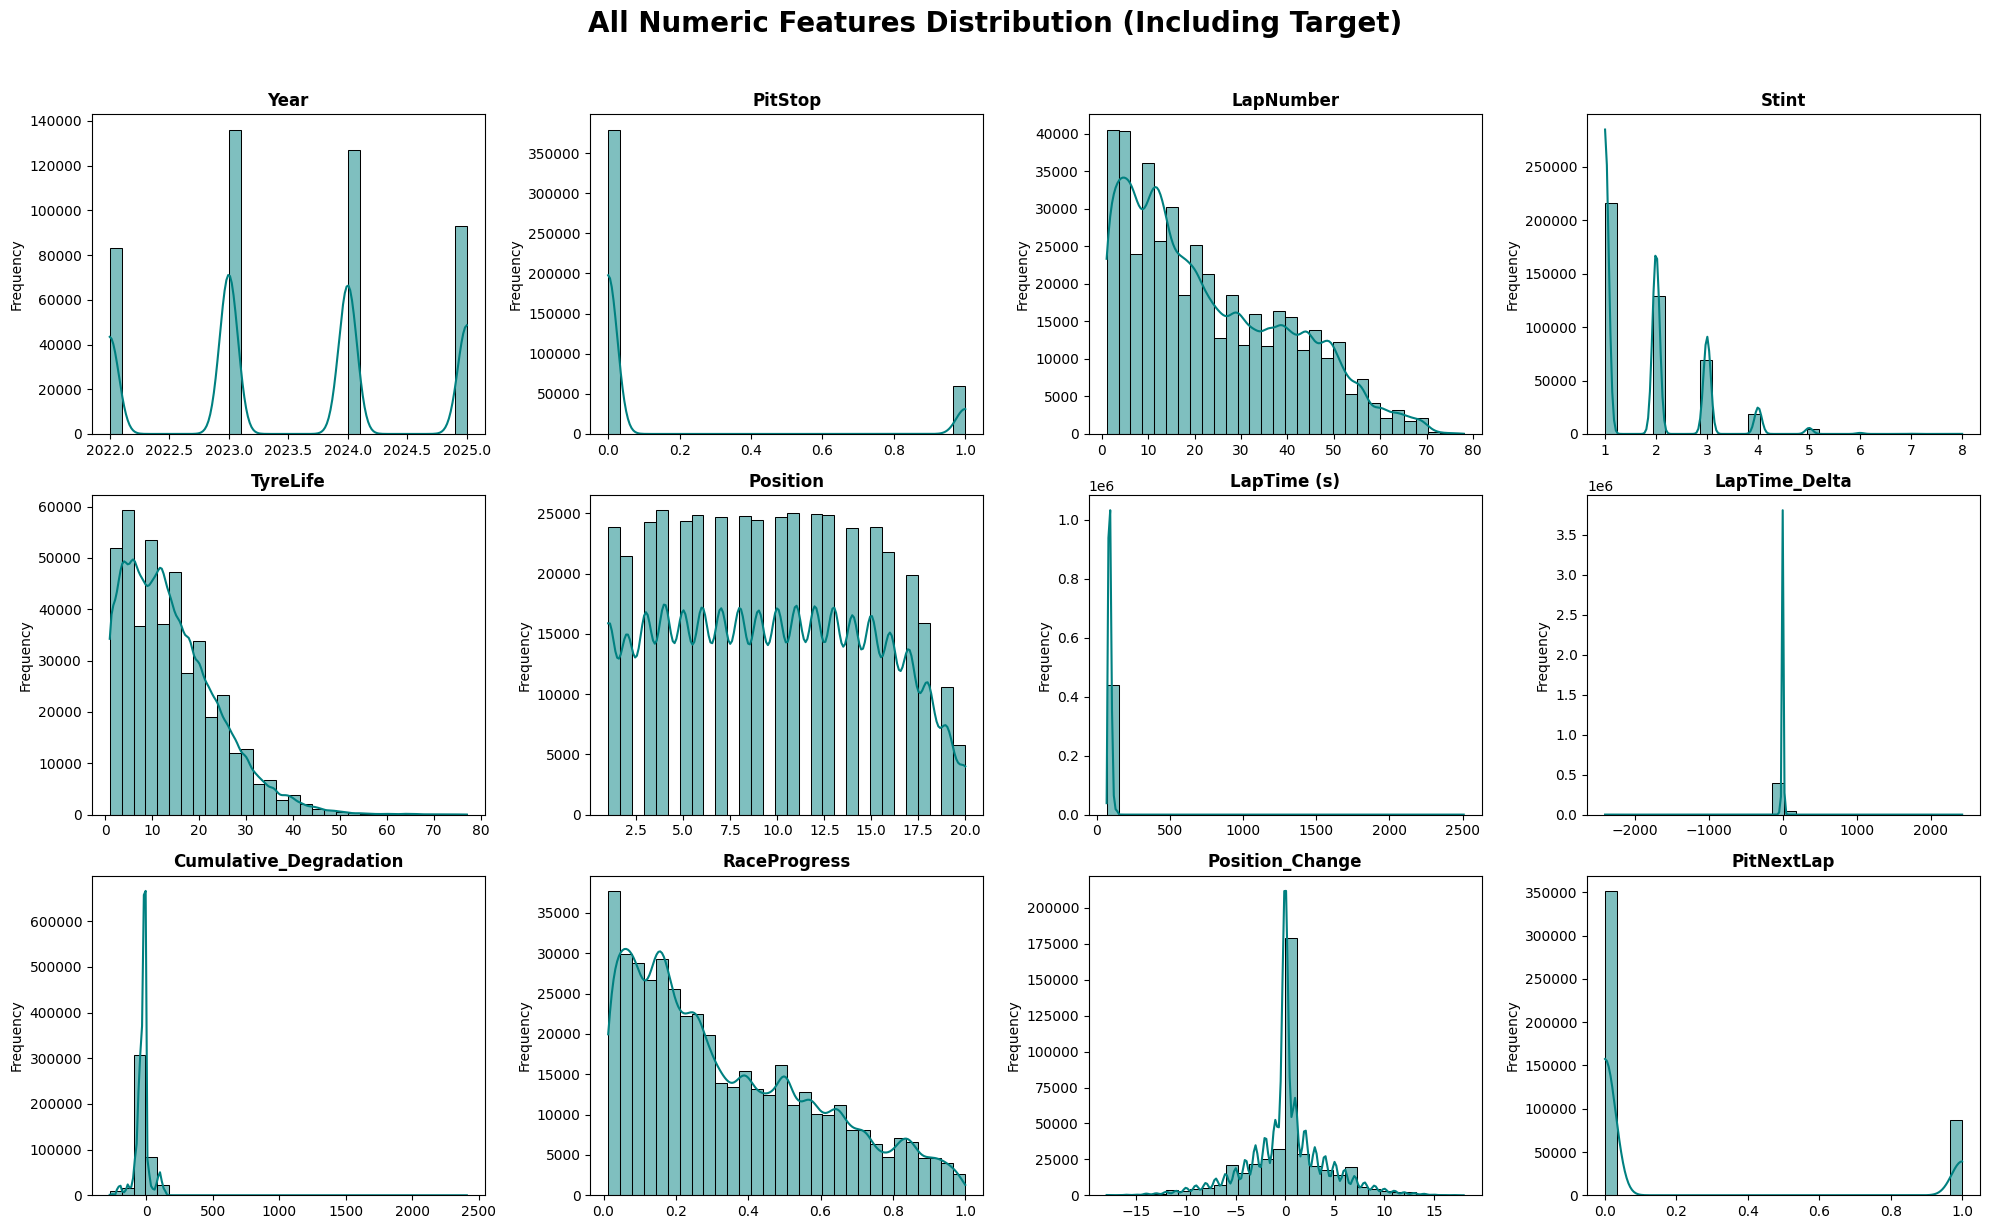

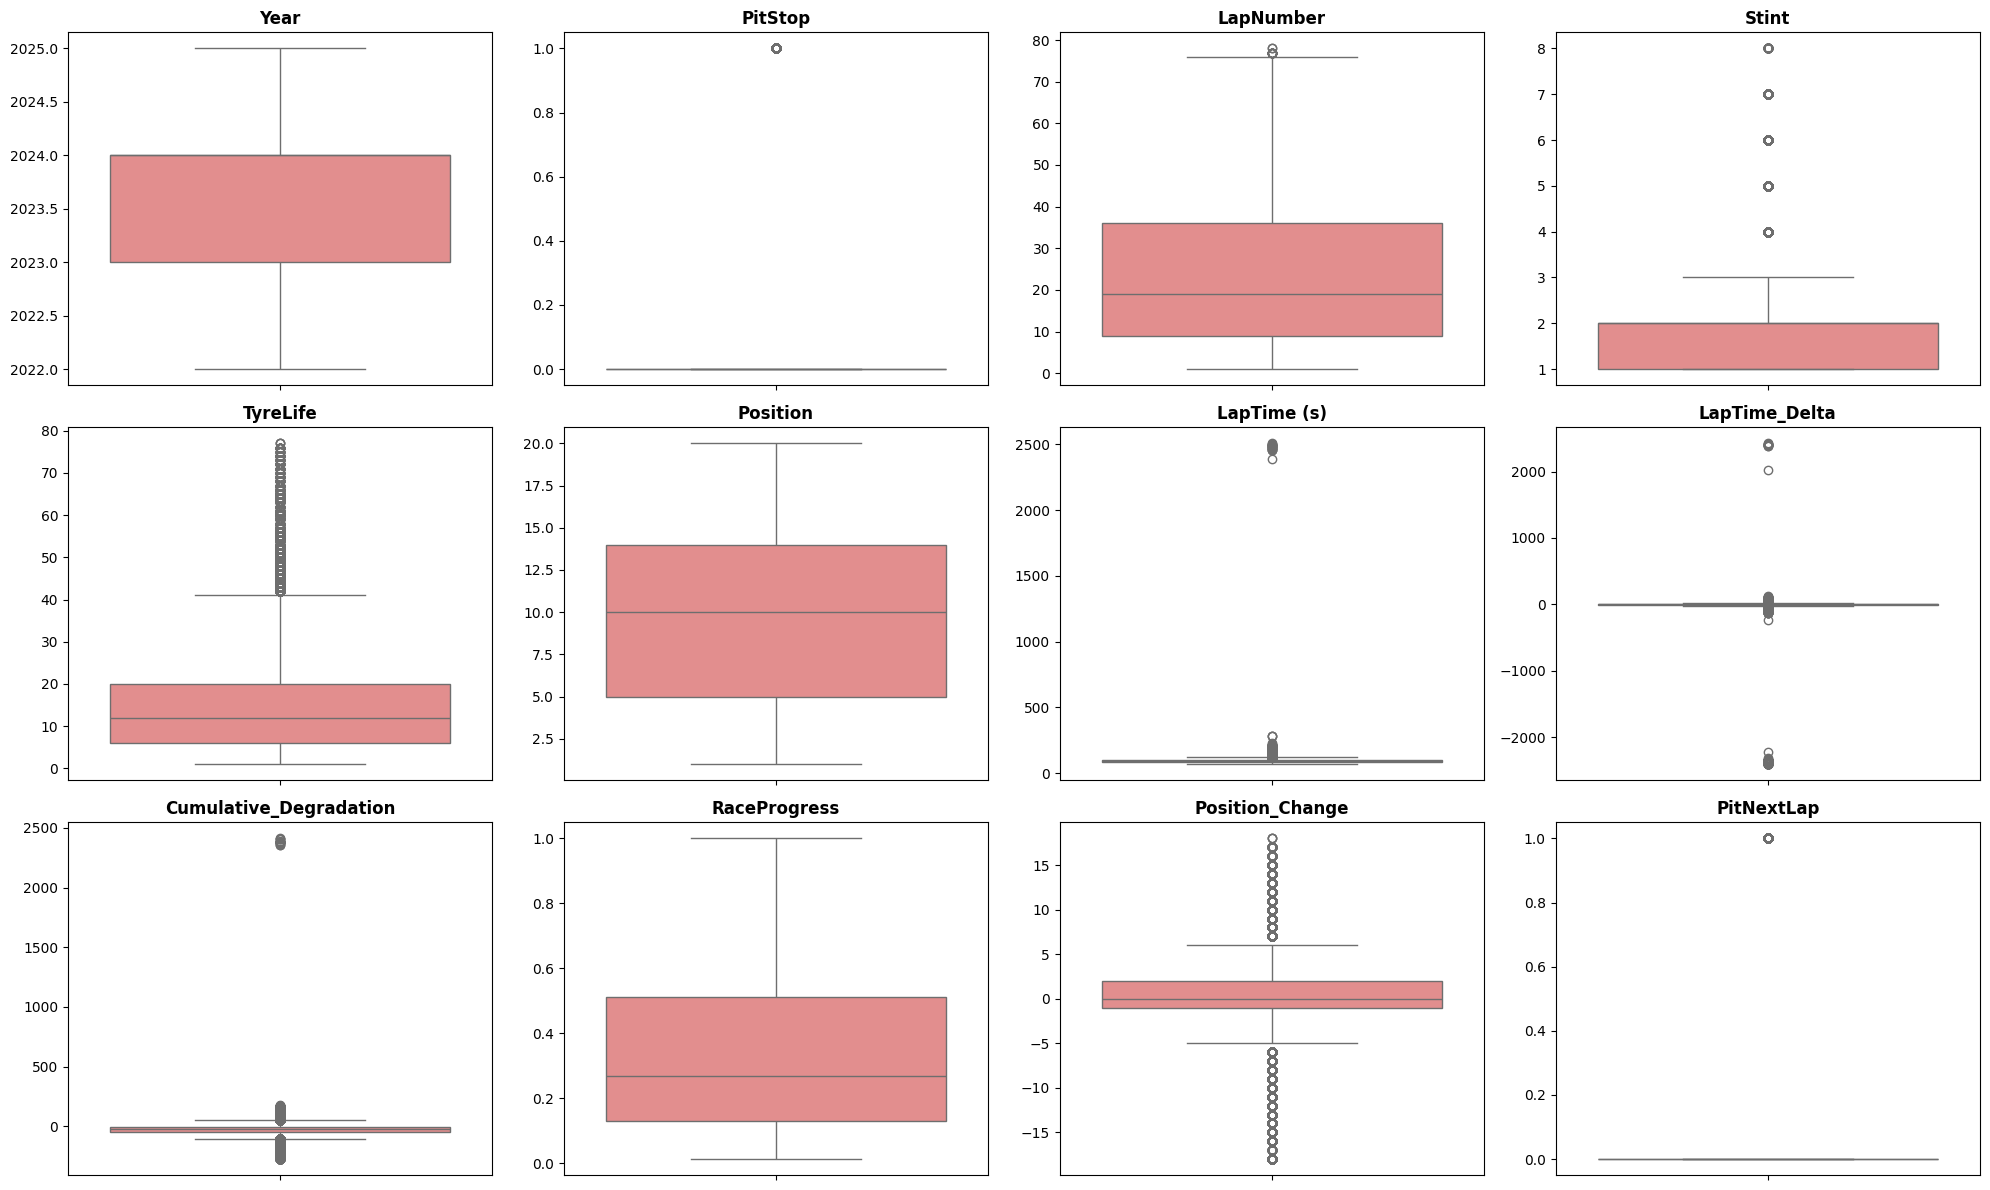

In [83]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore').columns.tolist()

num_plots = len(numeric_cols)
cols_per_row = 4
rows = math.ceil(num_plots / cols_per_row)

# Histogram
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for i in range(num_plots, len(axes)):
    axes[i].axis('off')

plt.suptitle('All Numeric Features Distribution (Including Target)', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=train_df[col].dropna(), ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

for i in range(num_plots, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

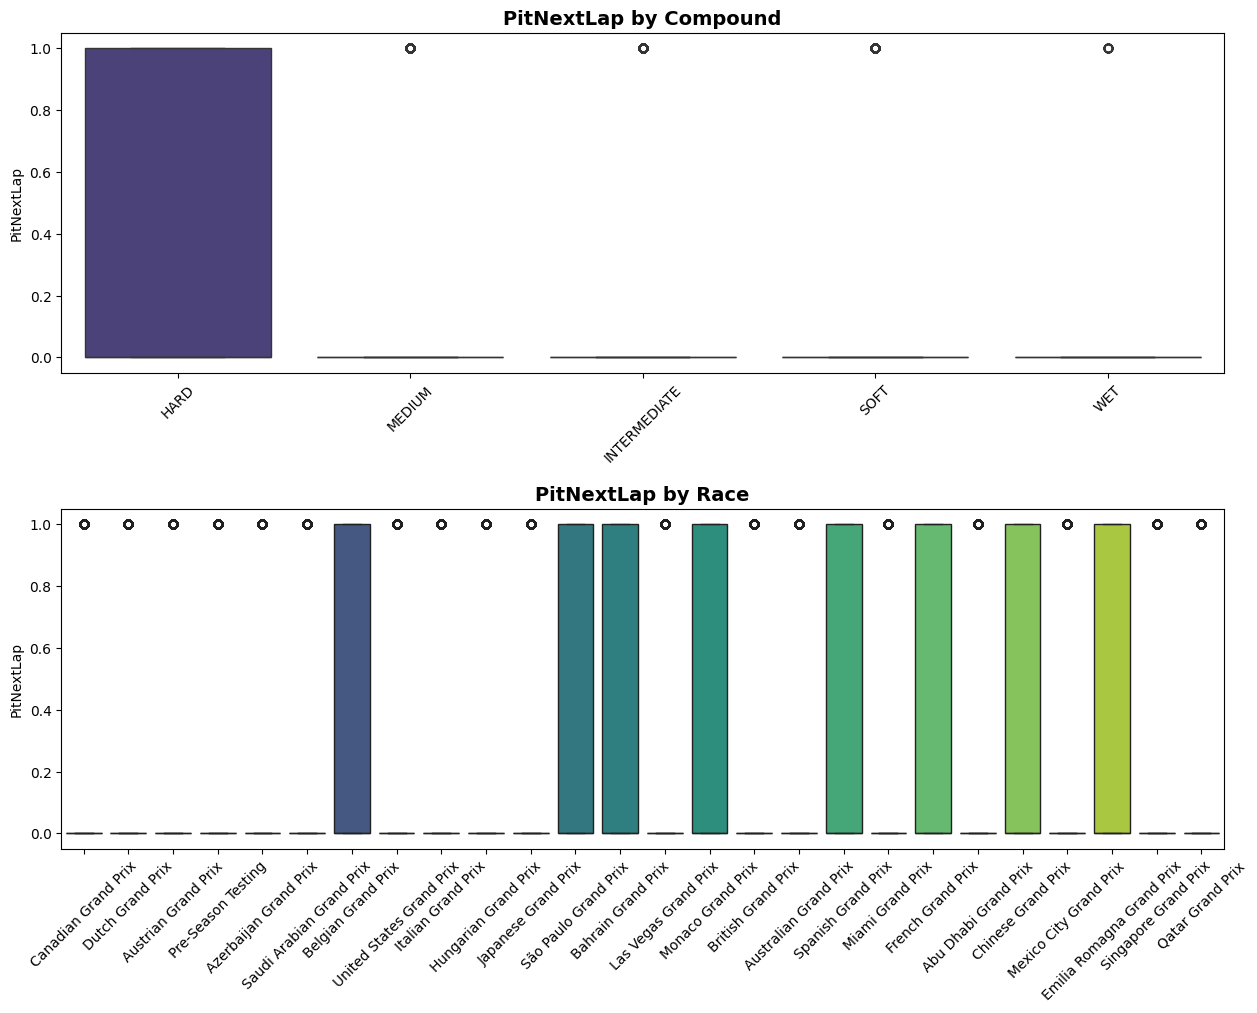

In [84]:
cat_cols = train_df.select_dtypes(include=['object', 'bool']).drop(columns=['Driver'], errors='ignore').columns.tolist()

num_plots = len(cat_cols)
cols_per_row = 1
rows = num_plots 

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, rows * 6))

if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=train_df, x=col, y='PitNextLap', ax=axes[i], palette='viridis')
    axes[i].set_title(f'PitNextLap by {col}', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45) # Etiketleri 45 derece eğdik
    axes[i].set_xlabel('')
    axes[i].set_ylabel('PitNextLap')

plt.subplots_adjust(bottom=0.2, hspace=0.4) 
plt.show()

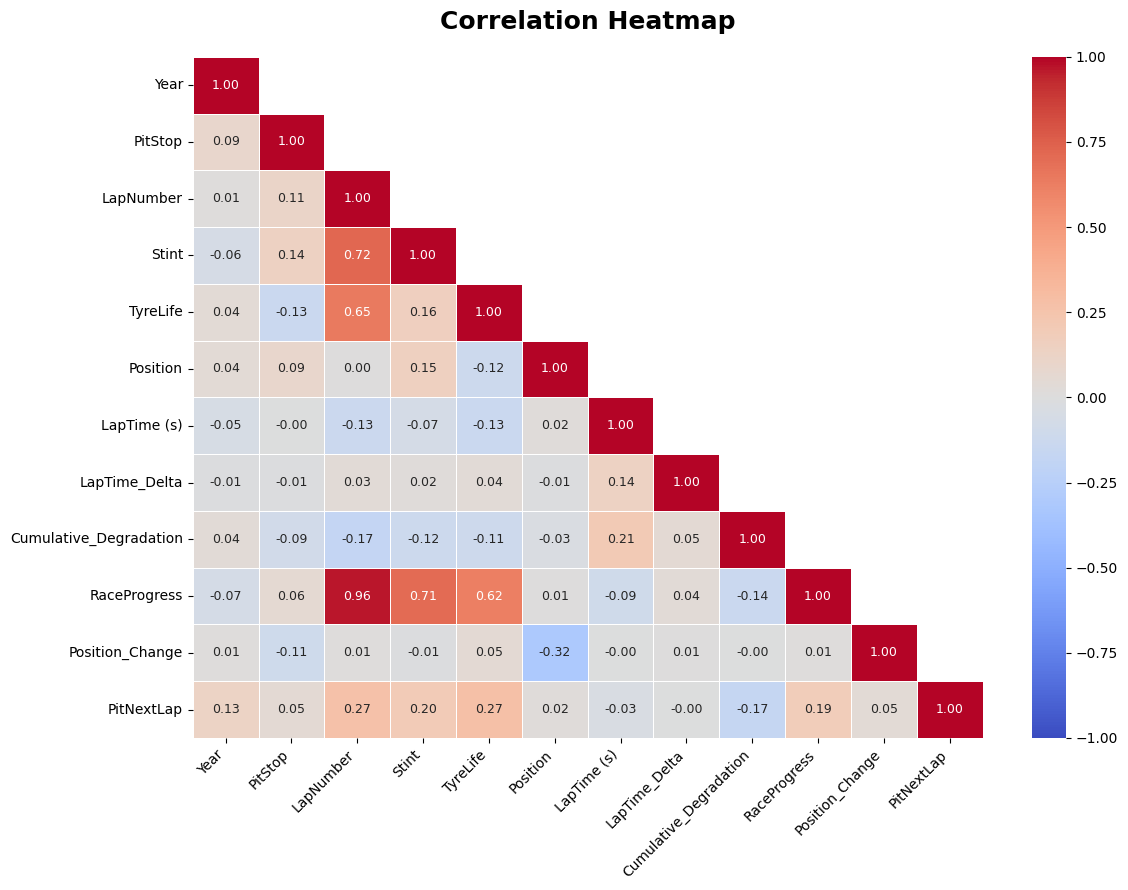

In [85]:
numeric_df = train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore')

corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 9))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f", 
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 9},
            vmax=1.0, vmin=-1.0)

plt.title('Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [86]:
# 1. Tyre Usage Rate: Normalizes tyre condition by dividing current life by the max life in the current stint.
train_df['Tyre_Usage_Rate'] = train_df['TyreLife'] / (train_df.groupby(['Race', 'Driver', 'Stint'])['TyreLife'].transform('max') + 1e-6)

# 2. Rolling LapTime Std: Measures performance volatility (tyre cliff indicator) over the last 3 laps using rolling directly.
train_df['Rolling_LapTime_Std'] = train_df.groupby(['Race', 'Driver', 'Stint'])['LapTime (s)'].rolling(window=3, min_periods=1).std().reset_index(level=[0,1,2], drop=True)

# 3. Position Momentum: Calculates the moving average of position changes using rolling directly.
train_df['Position_Momentum'] = train_df.groupby(['Race', 'Driver'])['Position_Change'].rolling(window=3, min_periods=1).mean().reset_index(level=[0,1], drop=True)

# 4. Stint Lap Count: Tracks the age of the current tyre set within the specific stint.
# We subtract the minimum lap number of the group from the current lap number and add 1.
train_df['Stint_Lap_Count'] = train_df['LapNumber'] - train_df.groupby(['Race', 'Driver', 'Stint'])['LapNumber'].transform('min') + 1

# 5. Degradation Velocity: Represents the rate of tyre decay by dividing cumulative degradation by lap number.
train_df['Degradation_Velocity'] = train_df['Cumulative_Degradation'] / (train_df['LapNumber'] + 1)

In [87]:
train_df.isna().sum()

id                            0
Driver                        0
Compound                      0
Race                          0
Year                          0
PitStop                       0
LapNumber                     0
Stint                         0
TyreLife                      0
Position                      0
LapTime (s)                   0
LapTime_Delta                 0
Cumulative_Degradation        0
RaceProgress                  0
Position_Change               0
PitNextLap                    0
Tyre_Usage_Rate               0
Rolling_LapTime_Std       47841
Position_Momentum             0
Stint_Lap_Count               0
Degradation_Velocity          0
dtype: int64

In [88]:
train_df['Rolling_LapTime_Std'] = train_df['Rolling_LapTime_Std'].fillna(0)

In [89]:
train_df.isna().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
Tyre_Usage_Rate           0
Rolling_LapTime_Std       0
Position_Momentum         0
Stint_Lap_Count           0
Degradation_Velocity      0
dtype: int64

In [90]:
# 1. Tyre Usage Rate: Normalizes tyre condition by dividing current life by the max life in the current stint.
test_df['Tyre_Usage_Rate'] = test_df['TyreLife'] / (test_df.groupby(['Race', 'Driver', 'Stint'])['TyreLife'].transform('max') + 1e-6)

# 2. Rolling LapTime Std: Measures performance volatility (tyre cliff indicator) over the last 3 laps using rolling directly.
test_df['Rolling_LapTime_Std'] = test_df.groupby(['Race', 'Driver', 'Stint'])['LapTime (s)'].rolling(window=3, min_periods=1).std().reset_index(level=[0,1,2], drop=True)

# 3. Position Momentum: Calculates the moving average of position changes using rolling directly.
test_df['Position_Momentum'] = test_df.groupby(['Race', 'Driver'])['Position_Change'].rolling(window=3, min_periods=1).mean().reset_index(level=[0,1], drop=True)

# 4. Stint Lap Count: Tracks the age of the current tyre set within the specific stint.
test_df['Stint_Lap_Count'] = test_df['LapNumber'] - test_df.groupby(['Race', 'Driver', 'Stint'])['LapNumber'].transform('min') + 1

# 5. Degradation Velocity: Represents the rate of tyre decay by dividing cumulative degradation by lap number.
test_df['Degradation_Velocity'] = test_df['Cumulative_Degradation'] / (test_df['LapNumber'] + 1)

In [92]:
test_df.isna().sum()

id                            0
Driver                        0
Compound                      0
Race                          0
Year                          0
PitStop                       0
LapNumber                     0
Stint                         0
TyreLife                      0
Position                      0
LapTime (s)                   0
LapTime_Delta                 0
Cumulative_Degradation        0
RaceProgress                  0
Position_Change               0
Tyre_Usage_Rate               0
Rolling_LapTime_Std       39297
Position_Momentum             0
Stint_Lap_Count               0
Degradation_Velocity          0
dtype: int64

In [93]:
test_df['Rolling_LapTime_Std'] = test_df['Rolling_LapTime_Std'].fillna(0)

In [94]:
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_df['Compound'] = ordinal_enc.fit_transform(train_df[['Compound']])
test_df['Compound'] = ordinal_enc.transform(test_df[['Compound']])

In [95]:
target_race = TargetEncoder()
train_df['Race'] = target_race.fit_transform(train_df[['Race']], train_df['PitNextLap'])
test_df['Race'] = target_race.transform(test_df[['Race']])

In [96]:
target_driver = TargetEncoder()
train_df['Driver'] = target_driver.fit_transform(train_df[['Driver']], train_df['PitNextLap'])
test_df['Driver'] = target_driver.transform(test_df[['Driver']])

In [97]:
test_df

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Tyre_Usage_Rate,Rolling_LapTime_Std,Position_Momentum,Stint_Lap_Count,Degradation_Velocity
0,439140,0.182308,2.0,0.133462,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0,0.875000,0.000000,0.000000,20,-0.226545
1,439141,0.356316,2.0,0.150547,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0,0.800000,0.000000,0.000000,23,-0.079600
2,439142,0.121796,2.0,0.133462,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0,1.000000,0.000000,0.000000,17,-0.353680
3,439143,0.198847,3.0,0.253713,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0,0.166667,0.000000,1.000000,1,1.178571
4,439144,0.197127,0.0,0.114051,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0,1.000000,0.000000,7.000000,31,-0.393358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188160,627300,0.177958,2.0,0.181572,2024,1,14,1,14.0,4,83.879,-16.919,-87.767,0.179487,-2.0,0.325581,0.711549,-0.666667,9,-5.851133
188161,627301,0.355904,3.0,0.146543,2025,0,60,3,26.0,4,95.727,7.920,-36.485,0.789474,-3.0,0.866667,4.192201,-0.666667,37,-0.598115
188162,627302,0.198847,2.0,0.239267,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,0.388889,3.0,1.000000,0.493693,4.333333,6,-0.011690
188163,627303,0.047126,2.0,0.357388,2024,0,20,2,15.0,7,80.074,-19.004,-37.967,0.256410,0.0,1.000000,0.000000,0.000000,1,-1.807952


In [98]:
x = train_df.drop(columns=['id', 'PitNextLap'], errors='ignore')
y = train_df['PitNextLap']
x_test_data = test_df.drop(columns=['id'], errors='ignore')

In [99]:
feature_columns = x.columns.tolist()

In [100]:
joblib.dump(feature_columns, 'feature_columns.joblib')

['feature_columns.joblib']

## 5. Model Training, Optimization & Deployment Strategy

In [101]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def algo_test(x, y):
    b = BernoulliNB()
    l = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
    d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
    r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
    kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ab = AdaBoostClassifier(random_state=42)
    svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42, dual="auto")
    xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', scale_pos_weight=4, random_state=42)
    lgb = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)
    et = ExtraTreesClassifier(n_estimators=100, class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    cb = CatBoostClassifier(iterations=100, learning_rate=0.05, verbose=0, auto_class_weights='Balanced', random_state=42)

    
    models = [b, l, d, r, gb, kn, ab, svc, xgb, lgb, et, cb]
    model_names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "LinearSVC", "XGBClassifier", "LGBMClassifier",
        "ExtraTreesClassifier", "CatBoostClassifier"
    ]

    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
        x, y, test_size=0.20, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train_split), columns=x_train_split.columns)
    x_val_scaled = pd.DataFrame(scaler.transform(x_val_split), columns=x_val_split.columns)
    
    accuracy, precision, recall, f1 = [], [], [], []
    successful_models = []
    successful_names = []

    for model, name in zip(models, model_names):
        print(f"--> Training {name}...")
        try:
            model_fitted = model.fit(x_train_scaled, y_train_split)
            prediction = model_fitted.predict(x_val_scaled)
            
            accuracy.append(accuracy_score(y_val_split, prediction))
            precision.append(precision_score(y_val_split, prediction, zero_division=0))
            recall.append(recall_score(y_val_split, prediction, zero_division=0))
            f1.append(f1_score(y_val_split, prediction, zero_division=0))
            
            successful_models.append(model_fitted)
            successful_names.append(name)
        except Exception as e:
            print(f" [!] Error executing pipeline for {name}: {e}")
            continue

    metrics = pd.DataFrame(index=successful_names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model_Object"] = successful_models

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("\n" + "="*50)
    best_model_name = metrics.index[0]
    print(f"TRUE MOST SUCCESSFUL MODEL BASED ON F1: {best_model_name}")
    print("="*50 + "\n")
    
    best_model_object = metrics.loc[best_model_name, "Model_Object"]
    final_prediction = best_model_object.predict(x_val_scaled)
    
    print(f"Real Confusion Matrix ({best_model_name}):")
    print(confusion_matrix(y_val_split, final_prediction))
    print(f"\nReal Classification Report ({best_model_name}):")
    print(classification_report(y_val_split, final_prediction))
    
    report_df = metrics.drop(columns=["Model_Object"])
    return report_df, metrics

In [102]:
report, full_metrics = algo_test(x, y)

--> Training BernoulliNB...
--> Training LogisticRegression...
--> Training DecisionTreeClassifier...
--> Training RandomForestClassifier...
--> Training GradientBoostingClassifier...
--> Training KNeighborsClassifier...
--> Training AdaBoostClassifier...
--> Training LinearSVC...
--> Training XGBClassifier...
--> Training LGBMClassifier...
--> Training ExtraTreesClassifier...
--> Training CatBoostClassifier...

TRUE MOST SUCCESSFUL MODEL BASED ON F1: ExtraTreesClassifier

Real Confusion Matrix (ExtraTreesClassifier):
[[66541  3811]
 [ 5693 11783]]

Real Classification Report (ExtraTreesClassifier):
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93     70352
         1.0       0.76      0.67      0.71     17476

    accuracy                           0.89     87828
   macro avg       0.84      0.81      0.82     87828
weighted avg       0.89      0.89      0.89     87828



In [103]:
report

,Accuracy,Precision,Recall,F1
ExtraTreesClassifier,0.891788,0.755611,0.674239,0.712610
LGBMClassifier,0.855001,0.590075,0.888590,0.709200
XGBClassifier,0.855206,0.590665,0.887045,0.709133
CatBoostClassifier,0.849786,0.581157,0.877489,0.699223
DecisionTreeClassifier,0.850230,0.583494,0.864157,0.696619
RandomForestClassifier,0.887838,0.758142,0.640707,0.694495
GradientBoostingClassifier,0.875734,0.715148,0.624056,0.666504
KNeighborsClassifier,0.872546,0.695336,0.639792,0.666408
AdaBoostClassifier,0.869267,0.702418,0.595102,0.644322
LinearSVC,0.763151,0.445483,0.777581,0.566444


In [104]:
x_raw_train, x_raw_val, y_raw_train, y_raw_val = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [105]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_raw_train)
x_val_scaled = scaler.transform(x_raw_val)

In [106]:
model = ExtraTreesClassifier(n_estimators=100, class_weight='balanced_subsample', n_jobs=-1, random_state=42)

In [107]:
model.fit(x_train_scaled, y_raw_train)

ExtraTreesClassifier(class_weight='balanced_subsample', n_jobs=-1,
                     random_state=42)

In [108]:
y_pred = model.predict(x_val_scaled)

In [109]:
print(classification_report(y_raw_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93     70352
         1.0       0.76      0.67      0.71     17476

    accuracy                           0.89     87828
   macro avg       0.84      0.81      0.82     87828
weighted avg       0.89      0.89      0.89     87828



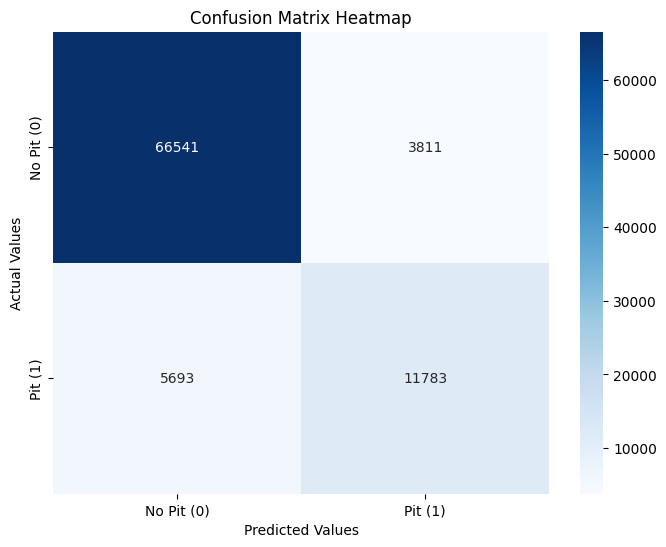

In [110]:
cm = confusion_matrix(y_raw_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Pit (0)', 'Pit (1)'], 
            yticklabels=['No Pit (0)', 'Pit (1)'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('Confusion Matrix Heatmap')
plt.show()

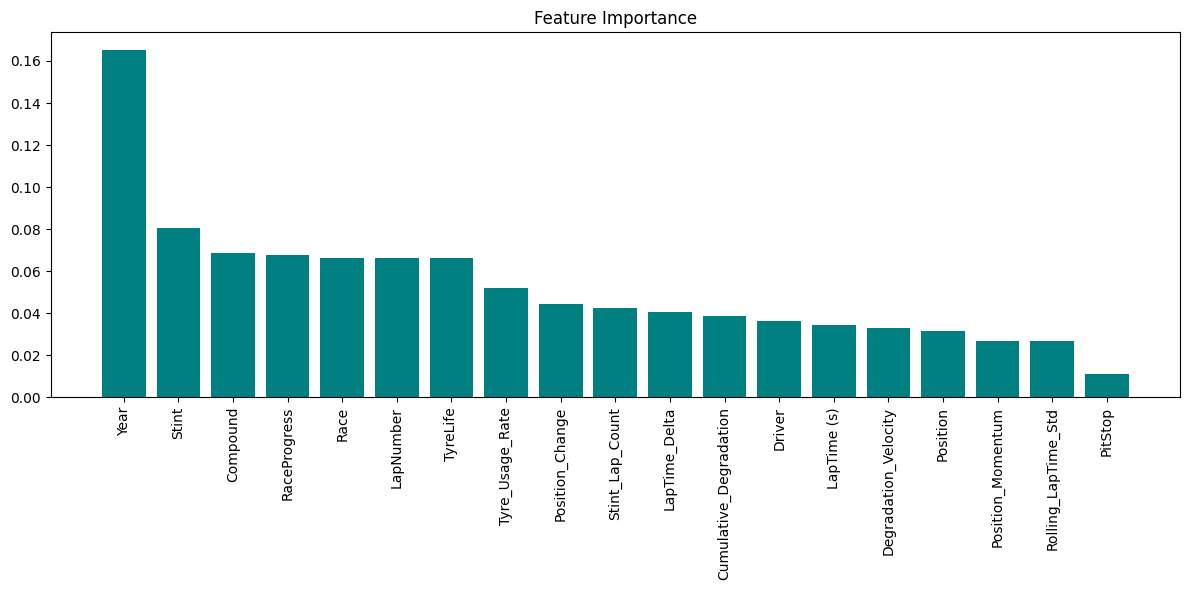

In [111]:
plt.figure(figsize=(12, 6))
importances = model.feature_importances_
feature_names = x_raw_train.columns
indices = np.argsort(importances)[::-1]

plt.title("Feature Importance")
plt.bar(range(x_raw_train.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(x_raw_train.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [112]:
x_final_train_scaled = scaler.fit_transform(x)
x_final_test_scaled = scaler.transform(x_test_data)

In [113]:
model.fit(x_final_train_scaled, y)

ExtraTreesClassifier(class_weight='balanced_subsample', n_jobs=-1,
                     random_state=42)

In [114]:
predictions = model.predict(x_final_test_scaled)

In [115]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'PitNextLap': predictions
})

submission.to_csv('final_pit_predictions_2.csv', index=False)

In [116]:
submission

,id,PitNextLap
0,439140,0.0
1,439141,0.0
2,439142,0.0
3,439143,0.0
4,439144,1.0
...,...,...
188160,627300,0.0
188161,627301,0.0
188162,627302,1.0
188163,627303,1.0


In [123]:
joblib.dump(model, 'f1_pit_model_2.joblib', compress=9)
joblib.dump(scaler, 'f1_pit_scaler_2.joblib')

with open('final_pit_model_2.pkl.gz', 'wb') as f:
    pickle.dump(model, f)
    
with open('f1_pit_scaler_2.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [124]:
display(FileLink('f1_pit_model_2.joblib'))

/kaggle/working/f1_pit_model_2.joblib

In [125]:
display(FileLink('final_pit_model_2.pkl.gz'))

/kaggle/working/final_pit_model_2.pkl.gz

In [126]:
joblib.dump(ordinal_enc, 'ordinal_enc.joblib', compress=9)

['ordinal_enc.joblib']

In [127]:
display(FileLink('ordinal_enc.joblib'))

/kaggle/working/ordinal_enc.joblib

In [128]:
joblib.dump(target_race, 'target_race.joblib')
joblib.dump(target_driver, 'target_driver.joblib')

['target_driver.joblib']

In [129]:
display(FileLink('target_race.joblib'))

/kaggle/working/target_race.joblib

In [130]:
display(FileLink('target_driver.joblib'))

/kaggle/working/target_driver.joblib